# EXP 1

## (i) Find-S Algorithm

In [8]:
import pandas as pd
data=pd.read_csv("enjoysport.csv")

concepts=data.iloc[:,:-1].values
target=data.iloc[:,-1].values

hypothesis=None

for i in range(len(concepts)):
    if target[i]=="Yes":
        if hypothesis is None:
            hypothesis = list(concepts[i])
        else:
            for j in range(len(hypothesis)):
                if hypothesis[j]!=concepts[i][j]:
                    hypothesis[j]="?"
print("Final Hypothesis:")
print(hypothesis)

Final Hypothesis:
['Sunny', 'Warm', '?', 'Strong', '?', '?']


## (ii) Candidate Elimination Algorithm

In [2]:
import pandas as pd
data=pd.read_csv("enjoysport.csv")

concepts=data.iloc[:,:-1].values
target=data.iloc[:,-1].values

s=list(concepts[0])
G=[['?' for i in range(len(s))] for j in range(len(s))]

for i in range(len(concepts)):
    if target[i]=="Yes":
        for j in range(len(s)):
            if s[j]!=concepts[i][j]:
                s[j]='?'
                G[j][j]='?'
                
    else:
        for j in range(len(s)):
            if s[j]!=concepts[i][j]:
                G[j][j]=s[j]
            else:
                G[j][j]='?'
                    
g_final=[]
for g in G:
    if g!=['?']*len(s):
        g_final.append(g)
                
print("Specific Hypothesis(s):")
print(s)

print("\nGeneral Hypothesis(G):")
for g in g_final:
    print(g)

Specific Hypothesis(s):
['Sunny', 'Warm', '?', 'Strong', '?', '?']

General Hypothesis(G):
['Sunny', '?', '?', '?', '?', '?']
['?', 'Warm', '?', '?', '?', '?']


## Version space

In [7]:
import pandas as pd
data=pd.read_csv("enjoysport.csv")

concepts=data.iloc[:,:-1].values
target=data.iloc[:,-1].values

s=list(concepts[0])
G=[['?' for i in range(len(s))] for j in range(len(s))]

for i in range(len(concepts)):
    if target[i]=="Yes":
        for j in range(len(s)):
            if s[j]!=concepts[i][j]:
                s[j]='?'
                G[j][j]='?'
                
    else:
        for j in range(len(s)):
            if s[j]!=concepts[i][j]:
                G[j][j]=s[j]
            else:
                G[j][j]='?'
                    
g_final=[]
for g in G:
    if g!=['?']*len(s):
        g_final.append(g)
                
print("Specific Hypothesis(s):")
print(s)

print("\nGeneral Hypothesis(G):")
for g in g_final:
    print(g)
    
    
vs=set()
vs.add(tuple(s))
for g in g_final:
    vs.add(tuple(g))
    for i in range(len(g)):
        if s[i]!=g[i]:
            nh=g.copy()
            nh[i]=s[i]
            vs.add(tuple(nh))
print("\nVersion Space:\n",vs,sep="")                   

Specific Hypothesis(s):
['Sunny', 'Warm', '?', 'Strong', '?', '?']

General Hypothesis(G):
['Sunny', '?', '?', '?', '?', '?']
['?', 'Warm', '?', '?', '?', '?']

Version Space:
{('Sunny', 'Warm', '?', '?', '?', '?'), ('?', 'Warm', '?', '?', '?', '?'), ('Sunny', 'Warm', '?', 'Strong', '?', '?'), ('Sunny', '?', '?', '?', '?', '?'), ('?', 'Warm', '?', 'Strong', '?', '?'), ('Sunny', '?', '?', 'Strong', '?', '?')}


# EXP 3

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
bagging = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50, random_state=42)
bagging.fit(X_train, y_train)
y_pred_bagging = bagging.predict(X_test)
bagging_acc = accuracy_score(y_test, y_pred_bagging)
boosting = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=50,algorithm="SAMME",random_state=42) 
boosting.fit(X_train, y_train)
y_pred_boosting = boosting.predict(X_test)
boosting_acc = accuracy_score(y_test, y_pred_boosting)
print("Bagging Accuracy:", bagging_acc)
print("Boosting Accuracy:", boosting_acc)
print("\n--- Bagging Classification Report ---")
print(classification_report(y_test, y_pred_bagging, target_names=iris.target_names))
print("\n--- Boosting Classification Report ---")
print(classification_report(y_test, y_pred_boosting, target_names=iris.target_names))

Bagging Accuracy: 0.9333333333333333
Boosting Accuracy: 0.9333333333333333

--- Bagging Classification Report ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      0.93      0.90        15
   virginica       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45


--- Boosting Classification Report ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      0.93      0.90        15
   virginica       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45



# EXP 2

# CN2

In [2]:
import pandas as pd
data = [
    ("sparrow", "bird", 1, 1), 
    ("eagle", "bird", 1, 1), 
    ("penguin", "bird", 0, 0), 
    ("bat", "mammal", 1, 1), 
    ("cat", "mammal", 0, 0), 
    ("butterfly", "insect", 1, 1)
]
columns = ["name", "type", "has_wings", "can_fly"]
df = pd.DataFrame(data, columns=columns)
print("Dataset:")
print(df)
print("\nCN2-like Classification Rules:")
for attribute in ["type", "has_wings"]:
    for value in df[attribute].unique():
        subset = df[df[attribute] == value]
        if subset["can_fly"].all():
            print(
                f"IF {attribute} = {value} "
                f"THEN can_fly = 1"
            )

Dataset:
        name    type  has_wings  can_fly
0    sparrow    bird          1        1
1      eagle    bird          1        1
2    penguin    bird          0        0
3        bat  mammal          1        1
4        cat  mammal          0        0
5  butterfly  insect          1        1

CN2-like Classification Rules:
IF type = insect THEN can_fly = 1
IF has_wings = 1 THEN can_fly = 1


/home/ailab/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# FOIL

In [3]:
import pandas as pd
import math

data = [
    ("sparrow", "bird", 1, 1),
    ("eagle", "bird", 1, 1),
    ("penguin", "bird", 0, 0),
    ("bat", "mammal", 1, 1),
    ("cat", "mammal", 0, 0),
    ("butterfly", "insect", 1, 1)
]

columns = ["name", "type", "has_wings", "can_fly"]

df = pd.DataFrame(data, columns=columns)

print("Dataset:")
print(df)

facts = {}

for _, row in df.iterrows():
    name = row["name"]
    facts[name] = set()

    facts[name].add(
        f"type({name},{row['type']})"
    )

    if row["has_wings"] == 1:
        facts[name].add(
            f"has_wings({name})"
        )

positive = []
negative = []

for _, row in df.iterrows():
    if row["can_fly"] == 1:
        positive.append(row["name"])
    else:
        negative.append(row["name"])

print("\nPositive Examples:")
print(positive)

print("\nNegative Examples:")
print(negative)

def satisfies(example, literal):
    fact = literal.replace("X", example)
    return fact in facts[example]

def covered(body, examples):
    result = []

    for example in examples:
        if all(
            satisfies(example, literal)
            for literal in body
        ):
            result.append(example)

    return result

def information_gain(p0, n0, p1, n1, t):
    if p1 == 0:
        return 0

    before = math.log2(
        p0 / (p0 + n0)
    )

    after = math.log2(
        p1 / (p1 + n1)
    )

    gain = t * (after - before)

    return gain

def calculate_gain(body, literal, current_positive, current_negative):
    p0 = len(current_positive)
    n0 = len(current_negative)

    new_body = body + [literal]

    new_positive = covered(
        new_body, current_positive
    )

    new_negative = covered(
        new_body, current_negative
    )

    p1 = len(new_positive)
    n1 = len(new_negative)

    t = p1

    gain = information_gain(
        p0, n0, p1, n1, t
    )

    return gain, new_positive, new_negative

def foil(positive, negative):
    learned_rules = []

    uncovered_positive = set(positive)

    while uncovered_positive:
        body = []

        current_positive = set(
            uncovered_positive
        )

        current_negative = set(
            negative
        )

        print("\n--------------------------------")
        print("Learning a new rule")
        print("--------------------------------")

        w hile current_negative:
            candidates = [
                "has_wings(X)",
                "type(X,bird)",
                "type(X,mammal)",
                "type(X,insect)"
            ]

            best_literal = None
            best_gain = float("-inf")

            print("\nCurrent rule body:", body)

            for literal in candidates:
                if literal in body:
                    continue

                gain, new_positive, new_negative = \
                calculate_gain(
                    body, literal, current_positive, current_negative
                )

                print(
                    f"{literal:20s} "
                    f"Gain = {gain:.4f}"
                )

                if gain > best_gain:
                    best_gain = gain
                    best_literal = literal

            if best_literal is None:
                break

            body.append(best_literal)

            current_positive = set(
                covered(
                    body, current_positive
                )
            )

            current_negative = set(
                covered(
                    body, current_negative
                )
            )

            print(
                "\nSelected literal:", best_literal
            )

            print(
                "Positive covered:", current_positive
            )

            print(
                "Negative covered:", current_negative
            )

        learned_rules.append(body)

        uncovered_positive -= current_positive

    return learned_rules

rules = foil(
    positive, negative
)

print("\n\n================================")
print("FINAL FOIL RULES")
print("================================")

for i, rule in enumerate(rules, 1):
    print(
        f"Rule {i}: "
        f"can_fly(X) :- "
        f"{', '.join(rule)}."
    )

Dataset:
        name    type  has_wings  can_fly
0    sparrow    bird          1        1
1      eagle    bird          1        1
2    penguin    bird          0        0
3        bat  mammal          1        1
4        cat  mammal          0        0
5  butterfly  insect          1        1

Positive Examples:
['sparrow', 'eagle', 'bat', 'butterfly']

Negative Examples:
['penguin', 'cat']

--------------------------------
Learning a new rule
--------------------------------

Current rule body: []
has_wings(X)         Gain = 2.3399
type(X,bird)         Gain = 0.0000
type(X,mammal)       Gain = -0.4150
type(X,insect)       Gain = 0.5850

Selected literal: has_wings(X)
Positive covered: {'butterfly', 'eagle', 'bat', 'sparrow'}
Negative covered: set()


FINAL FOIL RULES
Rule 1: can_fly(X) :- has_wings(X).


# EXP4

/home/ailab/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fbc5c6d27a0>
Traceback (most recent call last):
  File "/home/ailab/anaconda3/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/ailab/anaconda3/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/ailab/anaconda3/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/ailab/anaconda3/lib/python3.10/site-packages/threadpoolctl.py", li

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fbc5c6d36d0>
Traceback (most recent call last):
  File "/home/ailab/anaconda3/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/ailab/anaconda3/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/ailab/anaconda3/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/ailab/anaconda3/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Cluster Centers:
[[5.9016129  2.7483871  4.39354839 1.43387097]
 [5.006      3.428      1.462      0.246     ]
 [6.85       3.07368421 5.74210526 2.07105263]]


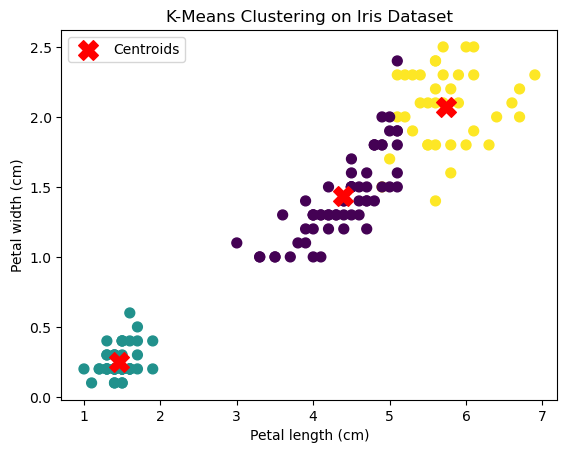

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
iris = load_iris()
data = pd.DataFrame(iris.data, columns=iris.feature_names)
kmeans = KMeans(n_clusters=3, random_state=42)
data['Cluster'] = kmeans.fit_predict(data)
print("Cluster Centers:")
print(kmeans.cluster_centers_)
plt.scatter(data['petal length (cm)'], data['petal width (cm)'], c=data['Cluster'], cmap='viridis', s=50)
plt.scatter(kmeans.cluster_centers_[:, 2], kmeans.cluster_centers_[:, 3], c='red', marker='X', s=200, label='Centroids')
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.title("K-Means Clustering on Iris Dataset")
plt.legend()
plt.show()

# EXP5

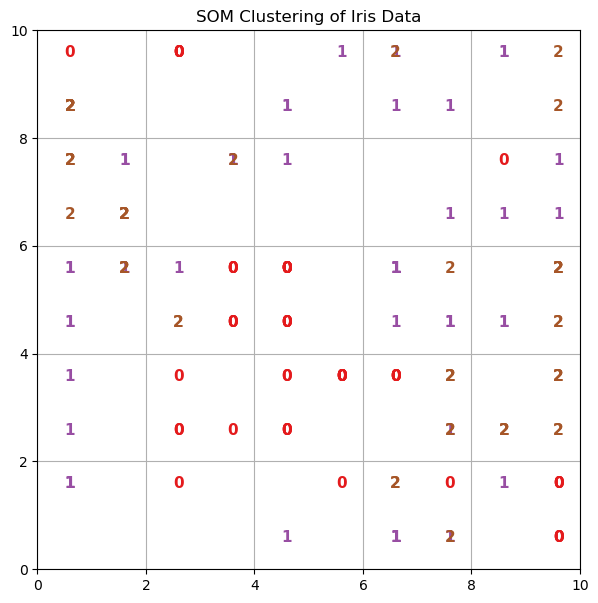

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from minisom import MiniSom
from sklearn import datasets
from sklearn.preprocessing import MinMaxScaler
iris=datasets.load_iris()
data=iris.data
target=iris.target
scaler=MinMaxScaler()
data=scaler.fit_transform(data)
som=MiniSom(x=10,y=10,input_len=4,sigma=1.0, learning_rate=0.5)
som.random_weights_init(data)
som.train_random(data,num_iteration=100)
plt.figure(figsize=(7,7))
for i,x in enumerate(data):
    w=som.winner(x)
    plt.text(w[0]+0.5,w[1]+0.5,str(target[i]),color=plt.cm.Set1(target[i]/3),fontdict={'weight':'bold','size':11})
plt.title('SOM Clustering of Iris Data')
plt.xlim([0,10])
plt.ylim([0,10])
plt.grid()
plt.show()

# EXP6

# (i) f(x)=x^2 